In [1]:
import requests
import pandas as pd
import numpy as np
from binance.client import Client
import datetime

from itertools import combinations
from statsmodels.tsa.stattools import coint
import statsmodels.api as sm


## Load Data and filter the top 20 by market cap

In [2]:
url = "https://api.coingecko.com/api/v3/coins/markets"

params = {
    "vs_currency": "usd",
    "order": "market_cap_desc",
    "per_page": 50,   # pull more so filtering still leaves ~20
    "page": 1,
    "sparkline": False
    
}

response = requests.get(url, params=params)
data = response.json()

df = pd.DataFrame(data)[
    ["market_cap_rank", "symbol", "name", "market_cap", "current_price"]
]

# -----------------------------
# Filters
# -----------------------------

stablecoins = {
    "usdt", "usdc", "busd", "dai", "tusd",
    "usdp", "fdusd", "gusd", "lusd",
    "ust", "ustc", "usdd", "eurc",'usds','usde','bsc-usd','usd1','pyusd'
    
}

# normalize text
df["symbol"] = df["symbol"].str.lower()
df["name"] = df["name"].str.lower()

# remove stablecoins
df = df[~df["symbol"].isin(stablecoins)]

# remove wrapped coins
df = df[
    ~df["name"].str.contains("wrapped") &
    ~df["symbol"].str.startswith("w")
]

# take top 20 after filtering
df = df.sort_values("market_cap", ascending=False).head(20)

print(df)


    market_cap_rank      symbol          name     market_cap  current_price
0                 1         btc       bitcoin  1478012837518   73795.000000
1                 2         eth      ethereum   265393295772    2197.990000
3                 4         bnb           bnb    92393010230     676.890000
4                 5         xrp           xrp    88684132455       1.450000
6                 7         sol        solana    52992069499      92.700000
7                 8         trx          tron    27510781789       0.290364
8                 9  figr_heloc  figure heloc    15955729813       1.008000
9                10        doge      dogecoin    15348532603       0.099916
12               13         ada       cardano    10249152357       0.278124
13               14         bch  bitcoin cash     9423516453     470.940000
14               15        hype   hyperliquid     8940377109      37.430000
15               16         leo     leo token     8360595541       9.070000
16          

## Get symbol from Binance, using binance data and later using binance api for trading test.


In [3]:
binance_symbols = requests.get(
    "https://api.binance.com/api/v3/exchangeInfo"
).json()

binance_assets = {
    s["baseAsset"].lower()
    for s in binance_symbols["symbols"]
    if s["quoteAsset"] == "USDT"
}

df = df[df["symbol"].isin(binance_assets)]

In [4]:
client = Client()


def get_close_prices_15m(
    client,
    symbols,
    start_date,
    end_date
):

    close_dfs = []

    for sym in symbols:
        pair = sym.upper() + "USDT"
        print(f"Downloading {pair}")

        klines = client.get_historical_klines(
            pair,
            Client.KLINE_INTERVAL_15MINUTE,
            start_date.strftime("%d %b %Y %H:%M:%S"),
            end_date.strftime("%d %b %Y %H:%M:%S")
        )

        df = pd.DataFrame(klines, columns=[
            "timestamp", "open", "high", "low", "close", "volume",
            "close_time", "quote_asset_volume", "number_of_trades",
            "taker_buy_base", "taker_buy_quote", "ignore"
        ])

        df = df[["timestamp", "close"]]
        df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")
        df["close"] = df["close"].astype(float)

        df = df.rename(columns={"close": sym.upper()})

        close_dfs.append(df)

    # ---- merge all coins on timestamp ----
    df_close = close_dfs[0]

    for d in close_dfs[1:]:
        df_close = df_close.merge(
            d,
            on="timestamp",
            how="outer"
        )

    df_close = (
        df_close
        .sort_values("timestamp")
        .set_index("timestamp")
    )

    return df_close


In [64]:
#start_date = datetime(2025, 1, 1)

end_date = datetime.datetime.now() #0-60 in total
in_sample_start_date = end_date - datetime.timedelta(days=30) # 30 days before end date
out_sample_start_date = end_date - datetime.timedelta(days=15) # 15 days before end date
start_date = end_date - datetime.timedelta(days=60) # 0 tian



total_df = get_close_prices_15m(
    client,
    df['symbol'].tolist(),
    start_date,
    end_date
)

### visualise price change over time

In [65]:
import numpy as np

base = total_df.iloc[0]
bad_cols = base[(base.isna()) | (base == 0)].index
print("Bad columns:", bad_cols)
total_df = total_df.drop(columns=bad_cols)

Bad columns: Index(['XMR'], dtype='object')


Text(0, 0.5, 'Price')

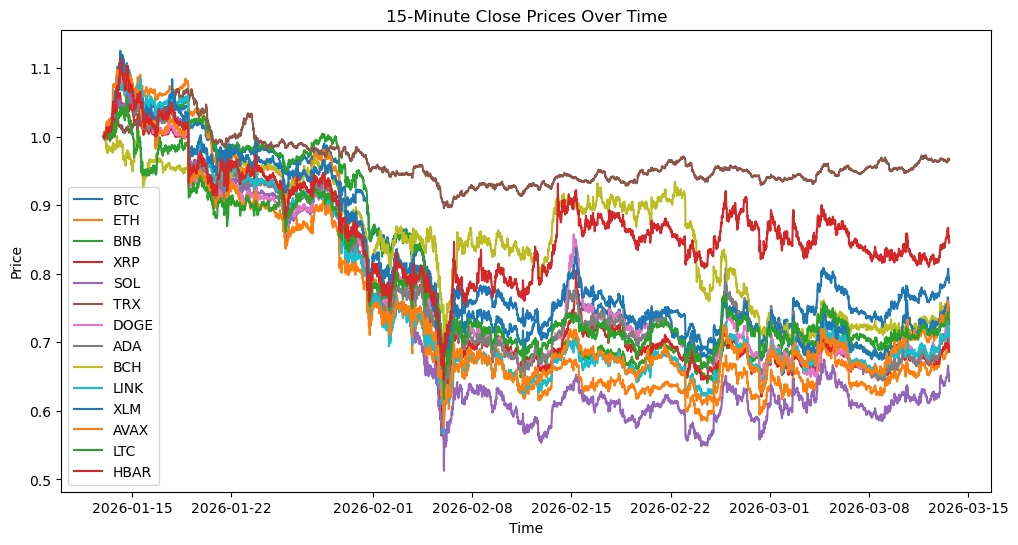

In [66]:
import matplotlib.pyplot as plt

normalized_df = total_df / total_df.iloc[0]  # Normalize to the first row

plt.figure(figsize=(12, 6))
for col in normalized_df.columns:
    plt.plot(normalized_df.index, normalized_df[col], label=col)
plt.legend()
plt.title("15-Minute Close Prices Over Time")
plt.xlabel("Time")
plt.ylabel("Price")

In [67]:
total_df.dropna(inplace=True, axis=0)

In [68]:
total_df.head()

,BTC,ETH,BNB,XRP,SOL,TRX,DOGE,ADA,BCH,LINK,XLM,AVAX,LTC,HBAR
timestamp,,,,,,,,,,,,,,
2026-01-13 00:00:00,91330.00,3100.74,904.81,2.0527,138.99,0.2998,0.13667,0.3865,622.3,13.08,0.2193,13.50,76.07,0.11501
2026-01-13 00:15:00,91444.51,3103.33,906.65,2.0569,139.10,0.2997,0.13690,0.3865,622.5,13.10,0.2194,13.53,75.96,0.11513
2026-01-13 00:30:00,91309.95,3101.72,905.77,2.0539,138.94,0.3001,0.13665,0.3859,621.5,13.09,0.2191,13.52,76.01,0.11486
2026-01-13 00:45:00,91482.74,3108.59,906.31,2.0593,139.30,0.3004,0.13698,0.3868,623.1,13.12,0.2199,13.55,75.99,0.11512
2026-01-13 01:00:00,91478.37,3110.37,907.16,2.0621,139.49,0.3001,0.13723,0.3878,624.1,13.15,0.2203,13.60,75.94,0.11542


## Run Cointegration Test
### select BTC related pairs

In [69]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from itertools import combinations

def test_cointegration_kalman(series_x, series_y, delta=1e-4):
    """
    Stationarity test using a Kalman Filter for dynamic hedge ratios
    """
    # 1️⃣ Kalman Filter to calculate rolling Alpha and Beta
    state_mean = np.zeros(2)
    state_cov = np.ones((2, 2))
    
    Q = (delta / (1 - delta)) * np.eye(2) 
    R = 1.0 
    
    rolling_alpha = []
    rolling_beta = []
    
    # Iterate through the time series
    for i in range(len(series_x)):
        x_t = series_x.iloc[i]
        y_t = series_y.iloc[i]
        
        H = np.array([[1.0, x_t]])
        
        # Prediction Step
        state_mean_pred = state_mean
        state_cov_pred = state_cov + Q
        
        # Update Step
        y_pred = H.dot(state_mean_pred)
        error = y_t - y_pred
        
        S = H.dot(state_cov_pred).dot(H.T) + R
        K = state_cov_pred.dot(H.T) / S
        
        state_mean = state_mean_pred + (K.flatten() * error)
        state_cov = (np.eye(2) - K.dot(H)).dot(state_cov_pred)
        
        rolling_alpha.append(state_mean[0])
        rolling_beta.append(state_mean[1])
        
    rolling_alpha = pd.Series(rolling_alpha, index=series_x.index)
    rolling_beta = pd.Series(rolling_beta, index=series_x.index)

    # 2️⃣ Calculate Dynamic Spread
    spread = series_y - (rolling_beta * series_x + rolling_alpha)

    # 3️⃣ Stationarity test (ADF) directly on the dynamic spread
    # We drop NA values that might occur during the initial filter convergence
    adf_result = adfuller(spread.dropna())
    
    t_stat = adf_result[0]
    pvalue = adf_result[1]
    crit_values = adf_result[4]

    return {
        "latest_beta": rolling_beta.iloc[-1], # Return the most recent beta for the summary table
        "pvalue": pvalue,
        "t_stat": t_stat,
        "crit_1%": crit_values['1%'],
        "crit_5%": crit_values['5%'],
        "crit_10%": crit_values['10%'],
        "spread": spread,
        "rolling_beta_series": rolling_beta # Stored in case you need to plot it later
    }


In [70]:
train_df = np.log(total_df[total_df.index < in_sample_start_date])
in_sample_df = total_df[total_df.index < out_sample_start_date]
out_sample_df = total_df[total_df.index >= out_sample_start_date]

In [71]:
in_sample_df

,BTC,ETH,BNB,XRP,SOL,TRX,DOGE,ADA,BCH,LINK,XLM,AVAX,LTC,HBAR
timestamp,,,,,,,,,,,,,,
2026-01-13 00:00:00,91330.00,3100.74,904.81,2.0527,138.99,0.2998,0.13667,0.3865,622.3,13.08,0.2193,13.50,76.07,0.11501
2026-01-13 00:15:00,91444.51,3103.33,906.65,2.0569,139.10,0.2997,0.13690,0.3865,622.5,13.10,0.2194,13.53,75.96,0.11513
2026-01-13 00:30:00,91309.95,3101.72,905.77,2.0539,138.94,0.3001,0.13665,0.3859,621.5,13.09,0.2191,13.52,76.01,0.11486
2026-01-13 00:45:00,91482.74,3108.59,906.31,2.0593,139.30,0.3004,0.13698,0.3868,623.1,13.12,0.2199,13.55,75.99,0.11512
2026-01-13 01:00:00,91478.37,3110.37,907.16,2.0621,139.49,0.3001,0.13723,0.3878,624.1,13.15,0.2203,13.60,75.94,0.11542
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-26 22:45:00,67572.30,2033.29,626.14,1.4024,86.15,0.2856,0.09694,0.2874,478.8,9.13,0.1626,9.33,55.46,0.10249
2026-02-26 23:00:00,67519.48,2029.73,625.17,1.3997,86.01,0.2856,0.09684,0.2872,478.8,9.11,0.1622,9.33,55.44,0.10282
2026-02-26 23:15:00,67569.44,2031.33,625.82,1.4017,86.01,0.2856,0.09703,0.2874,480.0,9.12,0.1625,9.33,55.72,0.10284


In [72]:

# --- Execution Loop ---
results = []
pairs = list(combinations(train_df.columns, 2))

for x, y in pairs:
    res = test_cointegration_kalman(train_df[x], train_df[y])

    results.append({
        "pair": f"{x}-{y}",
        "x": x,
        "y": y,
        "latest_beta": res["latest_beta"],
        "pvalue": res["pvalue"],
        "t_stat": res["t_stat"],
        "crit_5%": res["crit_5%"]
    })

# Format and filter the results
df_coint = pd.DataFrame(results)
coint_pairs = df_coint[df_coint["pvalue"] < 0.05]
coint_pairs = coint_pairs.sort_values("pvalue")

# Filter for pairs specifically involving BTC
btc_pairs = coint_pairs[
    (coint_pairs["x"] == "BTC") |
    (coint_pairs["y"] == "BTC")
]

display(btc_pairs)

,pair,x,y,latest_beta,pvalue,t_stat,crit_5%
4,BTC-TRX,BTC,TRX,-0.106436,4.799386e-21,-11.488524,-2.862545
7,BTC-BCH,BTC,BCH,0.515659,9.615201e-20,-10.934894,-2.862546
0,BTC-ETH,BTC,ETH,0.623547,1.774028e-16,-9.614619,-2.862549
12,BTC-HBAR,BTC,HBAR,-0.201376,5.137944e-15,-9.040869,-2.862550
11,BTC-LTC,BTC,LTC,0.324962,5.429178e-15,-9.031508,-2.862549
9,BTC-XLM,BTC,XLM,-0.156333,1.001832e-14,-8.927538,-2.862549
10,BTC-AVAX,BTC,AVAX,0.175930,1.592495e-14,-8.848920,-2.862550
8,BTC-LINK,BTC,LINK,0.172572,2.694046e-14,-8.759758,-2.862549
6,BTC-ADA,BTC,ADA,-0.114852,4.009985e-14,-8.692306,-2.862549
3,BTC-SOL,BTC,SOL,0.358584,1.618461e-13,-8.455562,-2.862550


fit garch

In [73]:
import pandas as pd
import numpy as np
from arch import arch_model

def get_garch_zscore(spread, window):
    """
    Fits an expanding GARCH(1,1) model to extract conditional volatility 
    and generates a volatility-adjusted Z-score.
    """
    # GARCH is typically fitted on the first difference of the spread (returns)
    spread_diff = spread.diff().dropna()
    garch_vol = pd.Series(index=spread.index, dtype=float)
    
    # Expanding window fit to prevent look-ahead bias
    for i in range(window, len(spread_diff)):
        train_data = spread_diff.iloc[:i]
        
        # Fit GARCH(1,1). rescale=True helps the optimizer converge on small price steps.
        am = arch_model(train_data, vol='Garch', p=1, q=1, rescale=True)
        res = am.fit(disp='off', update_freq=0)
        
        # Forecast 1-step ahead variance
        forecasts = res.forecast(horizon=1)
        garch_vol.iloc[i+1] = np.sqrt(forecasts.variance.values[-1, :][0]) / res.scale

    # Calculate Z-score using the conditional volatility
    # (Assuming the Kalman spread is already mean-centered around 0)
    garch_z_score = spread / garch_vol
    
    return garch_z_score, garch_vol

Analyzing the most cointegrated pair: BTC & TRX


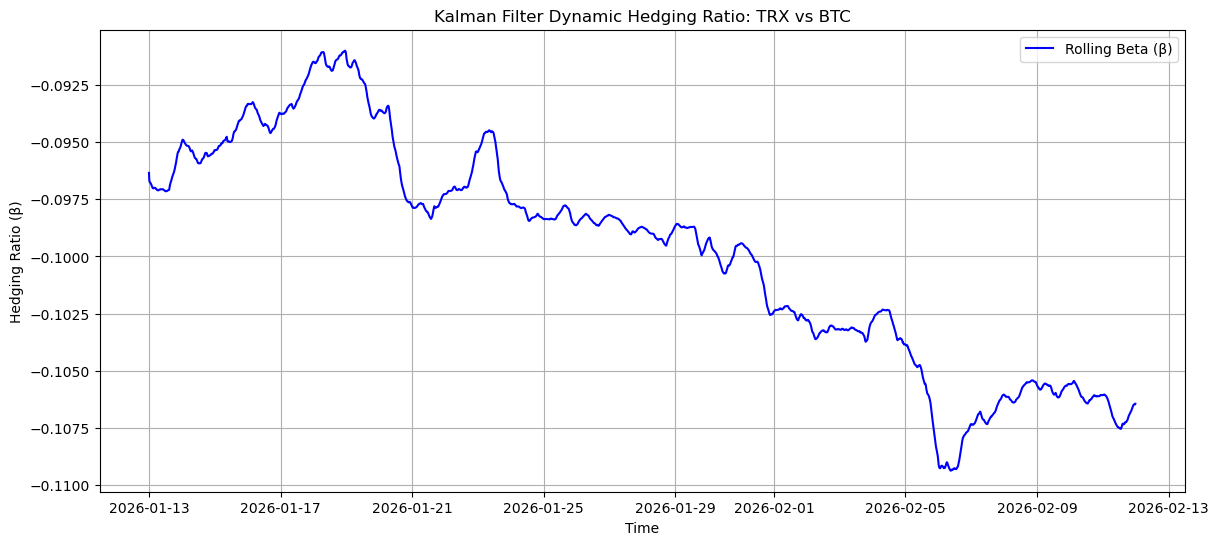

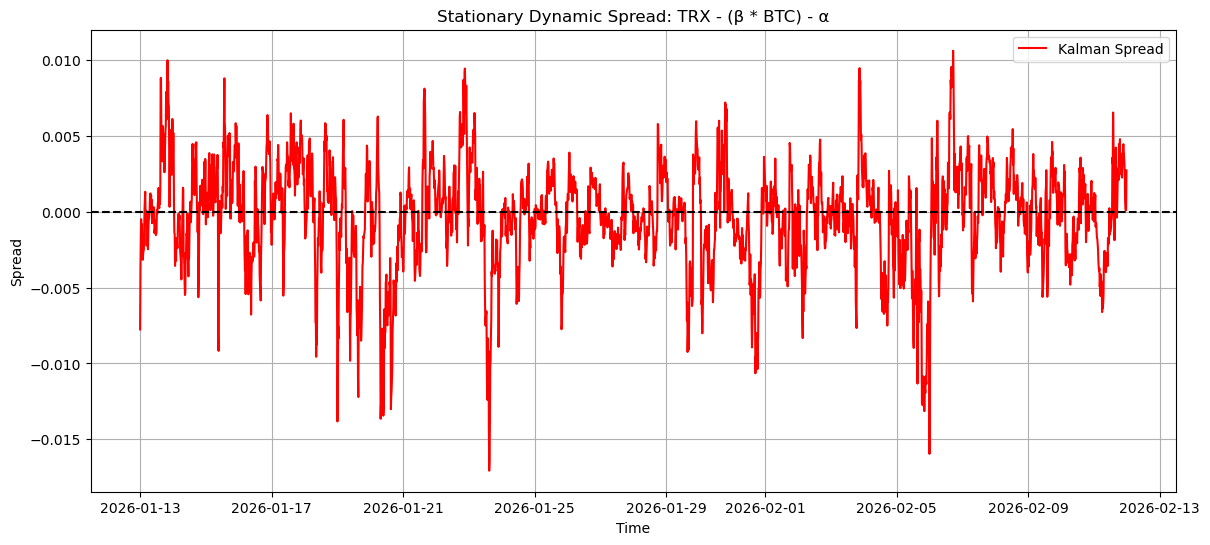

In [74]:
import matplotlib.pyplot as plt

# 1. Select the most cointegrated BTC pair (the one with the lowest p-value)
best_x = btc_pairs.iloc[0]['x']
best_y = btc_pairs.iloc[0]['y']
print(f"Analyzing the most cointegrated pair: {best_x} & {best_y}")

# 2. Re-run the Kalman Filter specifically for this pair to get the full time series
kalman_results = test_cointegration_kalman(train_df[best_x], train_df[best_y])

rolling_beta = kalman_results["rolling_beta_series"]
dynamic_spread = kalman_results["spread"]

# 3. Plot the Dynamic Hedging Ratio (Beta)
plt.figure(figsize=(14, 6))
plt.plot(rolling_beta.index, rolling_beta, label=f'Rolling Beta (\u03b2)', color='blue')
plt.title(f'Kalman Filter Dynamic Hedging Ratio: {best_y} vs {best_x}')
plt.xlabel('Time')
plt.ylabel('Hedging Ratio (\u03b2)')
plt.legend()
plt.grid(True)
plt.show()

# 4. Plot the resulting Dynamic Spread for visualization
plt.figure(figsize=(14, 6))
plt.plot(dynamic_spread.index, dynamic_spread, label='Kalman Spread', color='red')
plt.axhline(0, color='black', linestyle='--', lw=1.5)
plt.title(f'Stationary Dynamic Spread: {best_y} - (\u03b2 * {best_x}) - \u03b1')
plt.xlabel('Time')
plt.ylabel('Spread')
plt.legend()
plt.grid(True)
plt.show()

## Modelling

In [75]:


def build_spread(prices: pd.DataFrame, x: str, y: str, beta: float, use_log=True):
    px = prices[x].astype(float)
    py = prices[y].astype(float)
    if use_log:
        px = np.log(px)
        py = np.log(py)
    spread = py - beta * px
    return spread.dropna()

In [76]:
def fit_ou_from_spread(spread: pd.Series, delta=1.0):
    s = spread.values
    s_t = s[:-1]
    s_t1 = s[1:]

    X = sm.add_constant(s_t)
    res = sm.OLS(s_t1, X).fit()

    b = float(res.params[0])
    a = float(res.params[1])

    # guardrails
    if not (0 < a < 1):
        return None  # not mean-reverting in discrete-time sense

    eps = res.resid
    lam = -np.log(a) / delta
    mu = b / (1 - a)
    
    # --- OPTIMIZED GARCH CALCULATION ---
    # Instead of running an expanding window, fit GARCH ONCE 
    # on the residuals of the spread to get the model's volatility.
    try:
        am = arch_model(spread.diff().dropna(), vol='Garch', p=1, q=1, rescale=True)
        garch_res = am.fit(disp='off')
        
        # Use the annualized/scaled unconditional volatility of the GARCH model
        sigma = np.sqrt(garch_res.params['omega'] / (1 - garch_res.params['alpha[1]'] - garch_res.params['beta[1]'])) / garch_res.scale
    except:
        # Fallback to standard deviation if GARCH fails to converge
        sigma = float(np.std(eps, ddof=1)) 

    half_life = np.log(2) / lam

    return {
        "a": a, "b": b,
        "lambda": lam,
        "mu": mu,
        "sigma": sigma,
        "half_life": half_life,
        "r2": float(res.rsquared)
    }

In [77]:
def ou_zscore(spread: pd.Series, mu: float, sigma: float):
    return (spread - mu) / sigma

def percentile_signals(z: pd.Series, lookback=24*4, p_low=25, p_high=75, p_exit=50):
    sig = pd.Series(0, index=z.index, dtype=int)

    for i in range(lookback, len(z)):
        hist = z.iloc[i-lookback:i]
        lo = np.percentile(hist, p_low)
        hi = np.percentile(hist, p_high)
        mid = np.percentile(hist, p_exit)

        if z.iloc[i] > hi:
            sig.iloc[i] = -1   # short spread
        elif z.iloc[i] < lo:
            sig.iloc[i] = 1    # long spread
        elif (z.iloc[i-1] - mid) * (z.iloc[i] - mid) <= 0:
            sig.iloc[i] = 0    # exit when cross mid
        else:
            sig.iloc[i] = sig.iloc[i-1]  # hold previous position

    return sig

In [78]:
def walk_forward_signals(prices, x, y, train_window, trade_window):
    """
    Walk‑forward signal generation using the Kalman‑derived hedge ratio
    from the training window.
    """
    signals = []
    z_scores = []

    for start in range(train_window, len(prices) - trade_window, trade_window):
        train = prices.iloc[start - train_window:start]
        test  = prices.iloc[start:start + trade_window]

        # ---- 1. Obtain Kalman beta from training window ----
        # test_cointegration_kalman returns a dict with 'latest_beta'
        kalman_res = test_cointegration_kalman(train[x], train[y])
        beta = kalman_res["latest_beta"]   # float, final hedge ratio

        # ---- 2. Build spread using this beta ----
        spread_train = train[y] - beta * train[x]

        # ---- 3. Fit OU process to the spread ----
        ou = fit_ou_from_spread(spread_train)
        if ou is None:
            # Skip this window if OU parameters are invalid
            continue
        
        # ---- 4. Compute z‑score on test window ----
        spread_test = test[y] - beta * test[x]
        z = ou_zscore(spread_test, ou["mu"], ou["sigma"])

        # ---- 5. Generate trading signals ----
        lookback = max(10, len(z) // 4)   # at most 1/4 of test window
        sig = percentile_signals(z, lookback=lookback)

        signals.append(sig)
        z_scores.append(z)

        # ---- 4 & 5. Compute z-score and signals together ----
        # Combine train and test to give the percentile function enough history
        #combined_spread = pd.concat([spread_train, test[y] - beta * test[x]])
        #combined_z = ou_zscore(combined_spread, ou["mu"], ou["sigma"])
        
        # Calculate signals over the combined array
        #combined_sig = percentile_signals(combined_z, lookback=720)
        
        # Slice OUT only the test window to prevent look-ahead bias!
        #test_z = combined_z.iloc[-trade_window:]
        #test_sig = combined_sig.iloc[-trade_window:]

        #signals.append(test_sig)
        #z_scores.append(test_z)

    if not signals:
        # Return empty series if no windows succeeded
        return pd.Series(dtype=float), pd.Series(dtype=int)

    signals = pd.concat(signals)
    z_scores = pd.concat(z_scores)
    return z_scores, signals

In [79]:
def run_ou_for_pairs(pairs_df: pd.DataFrame, prices: pd.DataFrame, delta=1.0):
    results = []

    for _, row in pairs_df.iterrows():
        x, y, beta = row["x"], row["y"], float(row["latest_beta"])

        z, sig = walk_forward_signals(prices=in_sample_df, x=x, y=y,train_window=24*4*30,trade_window=24*4) # 20 days train, 1 day test
        results.append({
           "pair": f"{x}-{y}",
            "beta": beta,
            'z_scores' : z,
            "signal": sig
        })

    return results

In [80]:
ou_results = run_ou_for_pairs(btc_pairs, in_sample_df)

/var/folders/4m/pv0tzcg560gbwvkhsz_3dxsm0000gn/T/ipykernel_71609/2102887423.py:28: RuntimeWarning: invalid value encountered in sqrt
  sigma = np.sqrt(garch_res.params['omega'] / (1 - garch_res.params['alpha[1]'] - garch_res.params['beta[1]'])) / garch_res.scale
/var/folders/4m/pv0tzcg560gbwvkhsz_3dxsm0000gn/T/ipykernel_71609/2102887423.py:28: RuntimeWarning: invalid value encountered in sqrt
  sigma = np.sqrt(garch_res.params['omega'] / (1 - garch_res.params['alpha[1]'] - garch_res.params['beta[1]'])) / garch_res.scale
/var/folders/4m/pv0tzcg560gbwvkhsz_3dxsm0000gn/T/ipykernel_71609/2102887423.py:28: RuntimeWarning: invalid value encountered in sqrt
  sigma = np.sqrt(garch_res.params['omega'] / (1 - garch_res.params['alpha[1]'] - garch_res.params['beta[1]'])) / garch_res.scale
/var/folders/4m/pv0tzcg560gbwvkhsz_3dxsm0000gn/T/ipykernel_71609/2102887423.py:28: RuntimeWarning: invalid value encountered in sqrt
  sigma = np.sqrt(garch_res.params['omega'] / (1 - garch_res.params['alpha[1]'

In [81]:
ou_results

[{'pair': 'BTC-TRX',
  'beta': -0.10643614130574622,
  'z_scores': timestamp
  2026-02-12 00:00:00   -96.663929
  2026-02-12 00:15:00   -96.670169
  2026-02-12 00:30:00   -97.214873
  2026-02-12 00:45:00   -96.660918
  2026-02-12 01:00:00   -97.264323
                           ...    
  2026-02-25 22:45:00   -12.390332
  2026-02-25 23:00:00   -13.082496
  2026-02-25 23:15:00   -12.243878
  2026-02-25 23:30:00   -10.609515
  2026-02-25 23:45:00   -11.471263
  Length: 1344, dtype: float64,
  'signal': timestamp
  2026-02-12 00:00:00    0
  2026-02-12 00:15:00    0
  2026-02-12 00:30:00    0
  2026-02-12 00:45:00    0
  2026-02-12 01:00:00    0
                        ..
  2026-02-25 22:45:00   -1
  2026-02-25 23:00:00   -1
  2026-02-25 23:15:00   -1
  2026-02-25 23:30:00   -1
  2026-02-25 23:45:00   -1
  Length: 1344, dtype: int64},
 {'pair': 'BTC-BCH',
  'beta': 0.5156591221935217,
  'z_scores': timestamp
  2026-02-12 00:00:00   -159.554641
  2026-02-12 00:15:00   -160.219649
  2026-02

In [82]:

ou_df = pd.DataFrame([
    {
        "pair": r["pair"],
        "beta": r["beta"],
        "z_scores": r["z_scores"]
        
    }
    for r in ou_results
])




In [83]:
signals_df = pd.concat(
    {r["pair"]: r["signal"] for r in ou_results},
    axis=1
).sort_index()

In [84]:
signals_df

,BTC-TRX,BTC-BCH,BTC-ETH,BTC-HBAR,BTC-LTC,BTC-XLM,BTC-AVAX,BTC-LINK,BTC-ADA,BTC-SOL,BTC-DOGE,BTC-BNB,BTC-XRP
timestamp,,,,,,,,,,,,,
2026-02-12 00:00:00,0,0,0,0.0,0,0,0,0,0,0,0.0,0,0
2026-02-12 00:15:00,0,0,0,0.0,0,0,0,0,0,0,0.0,0,0
2026-02-12 00:30:00,0,0,0,0.0,0,0,0,0,0,0,0.0,0,0
2026-02-12 00:45:00,0,0,0,0.0,0,0,0,0,0,0,0.0,0,0
2026-02-12 01:00:00,0,0,0,0.0,0,0,0,0,0,0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-25 22:45:00,-1,1,-1,0.0,1,-1,1,-1,-1,-1,0.0,-1,-1
2026-02-25 23:00:00,-1,1,-1,0.0,1,0,0,-1,-1,-1,0.0,-1,1
2026-02-25 23:15:00,-1,1,-1,1.0,1,1,1,1,0,-1,1.0,-1,1


In [85]:


# -----------------------------
# Helpers: performance metrics
# -----------------------------
def _max_drawdown(equity: pd.Series) -> float:
    peak = equity.cummax()
    dd = equity / peak - 1.0
    return float(dd.min())

def _sharpe(returns: pd.Series, bars_per_year: int) -> float:
    r = returns.dropna()
    if len(r) < 2:
        return np.nan
    mu = r.mean()
    sd = r.std(ddof=1)
    if sd == 0:
        return np.nan
    return float((mu / sd) * np.sqrt(bars_per_year))

def _trade_stats(signal: pd.Series, pnl: pd.Series):
    """
    Approx trade stats using "position episodes" (when signal != 0).
    """
    s = signal.fillna(0).astype(int)
    pnl = pnl.fillna(0.0)

    # Episode start: 0 -> +/-1 ; Episode end: +/-1 -> 0 or sign flip
    changes = s.diff().fillna(s.iloc[0]).astype(int)

    # indices where a new position is entered
    entry_idx = s[(s != 0) & (changes != 0)].index
    # indices where position is exited (or flipped)
    exit_idx = s[(s == 0) & (changes != 0)].index

    # If last trade is still open, ignore it for winrate stats
    # Build episodes by walking entries and matching next exit
    episodes = []
    for ei in entry_idx:
        # find first exit after entry
        exits_after = exit_idx[exit_idx > ei]
        if len(exits_after) == 0:
            break
        xo = exits_after[0]
        ep_pnl = pnl.loc[ei:xo].sum()
        episodes.append(ep_pnl)

    if len(episodes) == 0:
        return {
            "num_trades": 0,
            "win_rate": np.nan,
            "avg_trade_pnl": np.nan,
            "median_trade_pnl": np.nan,
            "profit_factor": np.nan,
        }

    ep = np.array(episodes, dtype=float)
    wins = ep[ep > 0]
    losses = ep[ep < 0]

    profit_factor = np.nan
    if losses.size > 0:
        profit_factor = wins.sum() / (-losses.sum()) if wins.size > 0 else 0.0

    return {
        "num_trades": int(len(ep)),
        "win_rate": float((ep > 0).mean()),
        "avg_trade_pnl": float(ep.mean()),
        "median_trade_pnl": float(np.median(ep)),
        "profit_factor": float(profit_factor) if not np.isnan(profit_factor) else np.nan,
    }



In [86]:

# -----------------------------
# Core: perp pair backtester
# -----------------------------
def backtest_pair_perps(
    prices: pd.DataFrame,
    x: str,
    y: str,
    beta: float,
    signal: pd.Series,
    *,
    initial_capital: float = 10_000.0,
    leverage: float = 3.0,
    alloc: float = 1.0,                 # fraction of equity used for gross notional (before leverage)
    fee_rate: float = 0.0004,           # e.g. 4 bps taker; adjust for your assumed execution
    slippage_bps: float = 1.0,          # extra bps per notional traded (0..)
    bars_per_year: int = 365 * 24 * 4,  # 15m bars
    allow_flip_same_bar: bool = True,
) -> dict:
    """
    Signal convention (same as your notebook):
      +1 = long spread  -> LONG y, SHORT x * beta
      -1 = short spread -> SHORT y, LONG x * beta
       0 = flat

    PnL is linear perp-style:
      PnL_t = pos_units_prev * (price_t - price_{t-1}) summed across legs
    Fees/slippage are charged on traded NOTIONAL when position changes.
    """

    # Align & clean
    px = prices[x].astype(float).copy()
    py = prices[y].astype(float).copy()
    df = pd.concat([px.rename("px"), py.rename("py"), signal.rename("sig")], axis=1).dropna()
    df["sig"] = df["sig"].astype(int)

    if len(df) < 5:
        return {"pair": f"{x}-{y}", "df": df, "stats": {"error": "not enough data"}}

    # Containers
    equity = np.zeros(len(df), dtype=float)
    pnl = np.zeros(len(df), dtype=float)
    fees = np.zeros(len(df), dtype=float)

    # Position units (contracts) on each leg
    ux = np.zeros(len(df), dtype=float)
    uy = np.zeros(len(df), dtype=float)

    equity[0] = initial_capital

    prev_sig = 0
    prev_ux = 0.0
    prev_uy = 0.0

    # We use absolute beta weight for notional split
    w_x = abs(beta)
    w_y = 1.0
    denom = (w_x + w_y) if (w_x + w_y) != 0 else 1.0

    for i in range(1, len(df)):
        px_prev, py_prev = float(df["px"].iloc[i - 1]), float(df["py"].iloc[i - 1])
        px_now,  py_now  = float(df["px"].iloc[i]),     float(df["py"].iloc[i])
        sig_now = int(df["sig"].iloc[i])

        # 1) Mark-to-market from previous holdings
        mtm = prev_ux * (px_now - px_prev) + prev_uy * (py_now - py_prev)
        pnl[i] = mtm
        equity[i] = equity[i - 1] + mtm

        # 2) Decide target position (units) based on signal
        #    Notional sizing uses current equity AFTER mtm.
        #    Gross notional = equity * alloc * leverage
        gross = max(equity[i], 0.0) * float(alloc) * float(leverage)

        # Target notionals per leg (split by weights)
        ny = gross * (w_y / denom)
        nx = gross * (w_x / denom)

        # Convert to units (linear perp): units = notional / price
        if sig_now == 0:
            tgt_ux, tgt_uy = 0.0, 0.0
        elif sig_now == 1:
            # long spread: long y, short x*beta
            tgt_uy = + (ny / py_now)
            tgt_ux = - np.sign(beta) * (nx / px_now)  # beta sign determines hedge direction
        else:  # sig_now == -1
            tgt_uy = - (ny / py_now)
            tgt_ux = + np.sign(beta) * (nx / px_now)

        # 3) Trading costs if position changes
        # If you don't want flip-in-same-bar behavior, you can disallow it.
        changed = (sig_now != prev_sig)
        if changed and (not allow_flip_same_bar) and (prev_sig != 0) and (sig_now != 0):
            # force to flat first; then next bar will enter new side
            tgt_ux, tgt_uy = 0.0, 0.0
            sig_now = 0

        dx = tgt_ux - prev_ux
        dy = tgt_uy - prev_uy

        traded_notional = abs(dx) * px_now + abs(dy) * py_now
        cost = traded_notional * (fee_rate + (slippage_bps / 10_000.0))

        fees[i] = cost
        equity[i] -= cost  # deduct costs

        # 4) Set positions for next bar
        ux[i] = tgt_ux
        uy[i] = tgt_uy
        prev_ux, prev_uy = tgt_ux, tgt_uy
        prev_sig = int(df["sig"].iloc[i])

    out = df.copy()
    out["ux"] = ux
    out["uy"] = uy
    out["pnl"] = pnl
    out["fees"] = fees
    out["equity"] = equity
    out["ret"] = out["equity"].pct_change().fillna(0.0)

    # Turnover: traded notional / equity (rough)
    traded = (out["ux"].diff().abs() * out["px"] + out["uy"].diff().abs() * out["py"]).fillna(0.0)
    out["turnover"] = traded / out["equity"].replace(0, np.nan)

    stats = {
        "pair": f"{x}-{y}",
        "beta": float(beta),
        "initial_capital": float(initial_capital),
        "final_equity": float(out["equity"].iloc[-1]),
        "total_pnl": float(out["pnl"].sum() - out["fees"].sum()),
        "gross_pnl": float(out["pnl"].sum()),
        "total_fees": float(out["fees"].sum()),
        "sharpe": _sharpe(out["ret"], bars_per_year=bars_per_year),
        "max_drawdown": _max_drawdown(out["equity"]),
        "avg_turnover": float(out["turnover"].replace([np.inf, -np.inf], np.nan).dropna().mean())
                        if out["turnover"].notna().any() else np.nan,
    }
    stats.update(_trade_stats(out["sig"], out["pnl"] - out["fees"]))

    return {"pair": f"{x}-{y}", "df": out, "stats": stats}



In [87]:
in_sample_df

,BTC,ETH,BNB,XRP,SOL,TRX,DOGE,ADA,BCH,LINK,XLM,AVAX,LTC,HBAR
timestamp,,,,,,,,,,,,,,
2026-01-13 00:00:00,91330.00,3100.74,904.81,2.0527,138.99,0.2998,0.13667,0.3865,622.3,13.08,0.2193,13.50,76.07,0.11501
2026-01-13 00:15:00,91444.51,3103.33,906.65,2.0569,139.10,0.2997,0.13690,0.3865,622.5,13.10,0.2194,13.53,75.96,0.11513
2026-01-13 00:30:00,91309.95,3101.72,905.77,2.0539,138.94,0.3001,0.13665,0.3859,621.5,13.09,0.2191,13.52,76.01,0.11486
2026-01-13 00:45:00,91482.74,3108.59,906.31,2.0593,139.30,0.3004,0.13698,0.3868,623.1,13.12,0.2199,13.55,75.99,0.11512
2026-01-13 01:00:00,91478.37,3110.37,907.16,2.0621,139.49,0.3001,0.13723,0.3878,624.1,13.15,0.2203,13.60,75.94,0.11542
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-26 22:45:00,67572.30,2033.29,626.14,1.4024,86.15,0.2856,0.09694,0.2874,478.8,9.13,0.1626,9.33,55.46,0.10249
2026-02-26 23:00:00,67519.48,2029.73,625.17,1.3997,86.01,0.2856,0.09684,0.2872,478.8,9.11,0.1622,9.33,55.44,0.10282
2026-02-26 23:15:00,67569.44,2031.33,625.82,1.4017,86.01,0.2856,0.09703,0.2874,480.0,9.12,0.1625,9.33,55.72,0.10284


In [88]:

# -----------------------------
# Run it on your ou_results
# -----------------------------
all_stats = []
bt_results = {}

for r in ou_results:
    pair = r["pair"]          # e.g. "BTC-ETH"
    beta = r["beta"]
    sig = r["signal"]         # pd.Series indexed by timestamp (test period)

    x, y = pair.split("-")
    res = backtest_pair_perps(
        prices=in_sample_df.loc[sig.index],  # Use in-sample prices for backtesting the signals generated from the same period
        x=x, y=y,
        beta=beta,
        signal=sig,
        initial_capital=10_000,
        leverage=3.0,
        alloc=1,
        fee_rate=0.0004,
        slippage_bps=1.0,
        bars_per_year=365*24*4,  # 15m
    )

    bt_results[pair] = res
    all_stats.append(res["stats"])

stats_df = pd.DataFrame(all_stats).sort_values("sharpe", ascending=False)
stats_df

,pair,beta,initial_capital,final_equity,total_pnl,gross_pnl,total_fees,sharpe,max_drawdown,avg_turnover,num_trades,win_rate,avg_trade_pnl,median_trade_pnl,profit_factor
8,BTC-ADA,-0.114852,10000.0,6438.573349,-3561.426651,-656.079694,2905.346958,-5.491007,-0.545963,0.425222,92,0.641304,8.828569,62.858605,1.061273
10,BTC-DOGE,-0.200511,10000.0,6162.785836,-3837.214164,-1403.246599,2433.967565,-5.807988,-0.517574,0.400698,80,0.587500,-49.027859,64.974889,0.681538
1,BTC-BCH,0.515659,10000.0,7306.606389,-2693.393611,-734.137006,1959.256605,-7.641204,-0.285195,0.340041,74,0.459459,-18.829233,-10.420691,0.683985
3,BTC-HBAR,-0.201376,10000.0,6617.852789,-3382.147211,-1739.261571,1642.885640,-8.358955,-0.400495,0.418806,71,0.535211,-64.694852,10.361373,0.547994
5,BTC-XLM,-0.156333,10000.0,5349.043758,-4650.956242,-2380.304496,2270.651745,-9.651125,-0.506778,0.421745,91,0.439560,-73.166045,-25.334671,0.498194
7,BTC-LINK,0.172572,10000.0,5986.699636,-4013.300364,-1574.353643,2438.946722,-9.707293,-0.449796,0.458965,99,0.565657,-65.908579,20.967997,0.405307
6,BTC-AVAX,0.175930,10000.0,6160.601384,-3839.398616,-1187.312133,2652.086483,-9.837078,-0.457417,0.436562,95,0.515789,-22.401840,13.117489,0.764499
4,BTC-LTC,0.324962,10000.0,6692.101715,-3307.898285,-723.486825,2584.411460,-10.675437,-0.368453,0.425288,93,0.516129,-6.720317,8.202727,0.903694
2,BTC-ETH,0.623547,10000.0,8514.884231,-1485.115769,-587.635530,897.480239,-11.121213,-0.178569,0.138723,30,0.300000,-79.780501,-12.802295,0.082110
9,BTC-SOL,0.358584,10000.0,5994.810365,-4005.189635,-2239.259431,1765.930204,-12.944617,-0.448981,0.359421,77,0.623377,-42.964759,25.739272,0.526119


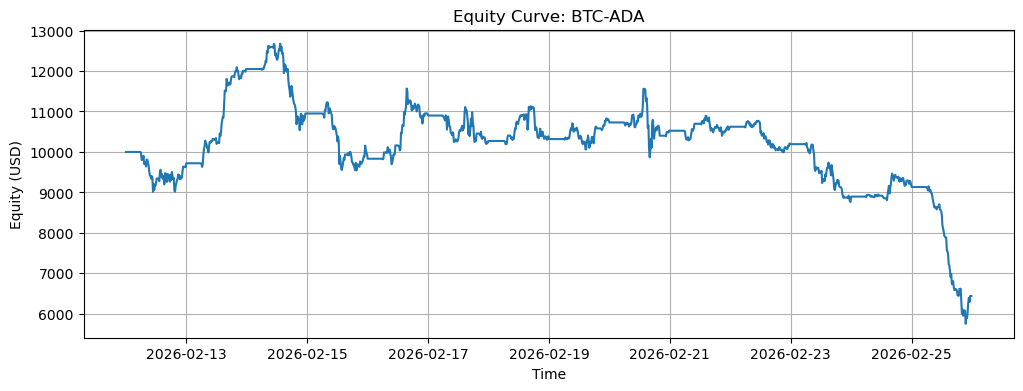

{'pair': 'BTC-ADA',
 'beta': -0.11485199591451567,
 'initial_capital': 10000.0,
 'final_equity': 6438.573348557155,
 'total_pnl': -3561.426651442839,
 'gross_pnl': -656.0796936288691,
 'total_fees': 2905.34695781397,
 'sharpe': -5.491007210739992,
 'max_drawdown': -0.5459626790244749,
 'avg_turnover': 0.42522244277061133,
 'num_trades': 92,
 'win_rate': 0.6413043478260869,
 'avg_trade_pnl': 8.828568678797273,
 'median_trade_pnl': 62.858605350030224,
 'profit_factor': 1.061273075869993}

In [89]:
import matplotlib.pyplot as plt

best_pair = stats_df.iloc[0]["pair"]
eq = bt_results[best_pair]["df"]["equity"]

plt.figure(figsize=(12,4))
plt.plot(eq.index, eq.values)
plt.title(f"Equity Curve: {best_pair}")
plt.xlabel("Time")
plt.ylabel("Equity (USD)")
plt.grid(True)
plt.show()

bt_results[best_pair]["stats"]

In [90]:
def build_trade_log(bt_df: pd.DataFrame):

    trades = []
    position = 0
    entry_time = None
    entry_px = None
    entry_py = None

    for i in range(1, len(bt_df)):

        sig_prev = bt_df["sig"].iloc[i-1]
        sig_now  = bt_df["sig"].iloc[i]

        px = bt_df["px"].iloc[i]
        py = bt_df["py"].iloc[i]
        time = bt_df.index[i]

        # ENTRY
        if position == 0 and sig_now != 0:
            position = sig_now
            entry_time = time
            entry_px = px
            entry_py = py

        # EXIT
        elif position != 0 and sig_now == 0:

            exit_time = time
            exit_px = px
            exit_py = py

            pnl = bt_df.loc[entry_time:exit_time, "pnl"].sum() \
                  - bt_df.loc[entry_time:exit_time, "fees"].sum()

            trades.append({
                "entry_time": entry_time,
                "exit_time": exit_time,
                "direction": "long_spread" if position == 1 else "short_spread",
                "entry_px_x": entry_px,
                "entry_px_y": entry_py,
                "exit_px_x": exit_px,
                "exit_px_y": exit_py,
                "holding_minutes": (exit_time - entry_time).total_seconds() / 60,
                "pnl": pnl
            })

            position = 0
            entry_time = None

        # FLIP POSITION
        elif position != 0 and sig_now == -position:

            exit_time = time
            exit_px = px
            exit_py = py

            pnl = bt_df.loc[entry_time:exit_time, "pnl"].sum() \
                  - bt_df.loc[entry_time:exit_time, "fees"].sum()

            trades.append({
                "entry_time": entry_time,
                "exit_time": exit_time,
                "direction": "long_spread" if position == 1 else "short_spread",
                "entry_px_x": entry_px,
                "entry_px_y": entry_py,
                "exit_px_x": exit_px,
                "exit_px_y": exit_py,
                "holding_minutes": (exit_time - entry_time).total_seconds() / 60,
                "pnl": pnl
            })

            # new position
            position = sig_now
            entry_time = time
            entry_px = px
            entry_py = py

    return pd.DataFrame(trades)

In [91]:
bt_df = bt_results[best_pair]["df"]

trade_log = build_trade_log(bt_df)

trade_log

,entry_time,exit_time,direction,entry_px_x,entry_px_y,exit_px_x,exit_px_y,holding_minutes,pnl
0,2026-02-12 06:00:00,2026-02-12 12:15:00,short_spread,67118.00,0.2600,67985.12,0.2656,375.0,-655.614718
1,2026-02-12 12:45:00,2026-02-12 14:30:00,long_spread,67865.31,0.2649,67625.01,0.2654,105.0,5.046351
2,2026-02-12 14:45:00,2026-02-12 15:30:00,short_spread,67577.02,0.2657,67400.41,0.2641,45.0,123.226930
3,2026-02-12 16:00:00,2026-02-12 16:30:00,long_spread,66558.41,0.2601,66271.97,0.2603,30.0,-24.613580
4,2026-02-12 17:00:00,2026-02-12 22:00:00,short_spread,65740.35,0.2591,65816.45,0.2594,300.0,-99.753725
...,...,...,...,...,...,...,...,...,...
87,2026-02-24 18:15:00,2026-02-24 22:00:00,long_spread,64292.00,0.2611,64219.60,0.2606,225.0,-81.942840
88,2026-02-24 22:45:00,2026-02-25 00:00:00,long_spread,64120.95,0.2594,63919.23,0.2581,75.0,-162.255830
89,2026-02-25 06:00:00,2026-02-25 18:15:00,short_spread,64989.10,0.2647,69348.39,0.2978,735.0,-2677.908442
90,2026-02-25 18:45:00,2026-02-25 19:00:00,short_spread,69328.07,0.2991,68915.55,0.2962,15.0,161.022117
